In [1]:
#1.INSTALL & IMPORT
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
#2.LOAD DATA

data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

#Fix MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)


/tmp/ipykernel_12551/4263841326.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


We are using Apple (AAPL) stock data from 2020 to 2024.
- Columns include Open, High, Low, Close, Adj Close, and Volume.
 - This dataset will be used for short-term closing price prediction.
 - 'Close' column will be the main target variable for our ml models.

In [3]:
#3.EDA (EXPLORATORY DATA ANALYSIS)

print("Shape:", data.shape)
print("\nMissing Values:\n", data.isnull().sum())
print("\nBasic Stats:\n", data.describe())


Shape: (1006, 5)

Missing Values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Basic Stats:
 Price        Close         High          Low         Open        Volume
count  1006.000000  1006.000000  1006.000000  1006.000000  1.006000e+03
mean    137.957993   139.439050   136.328683   137.827953  9.895373e+07
std      33.357830    33.477922    33.218687    33.351565  5.439610e+07
min      54.213600    55.211516    51.372081    55.110034  2.404830e+07
25%     120.397032   121.638025   118.864121   120.502568  6.407675e+07
50%     142.816360   144.390231   141.154830   142.666155  8.467540e+07
75%     163.195045   165.471095   161.941460   163.462846  1.155069e+08
max     196.073120   197.567590   194.974519   195.984049  4.265100e+08


###Exploratory Data Analysis (EDA) Summary — Apple Stock (AAPL)

The dataset contains 1,006 daily records of Apple stock prices from January 1, 2020, to January 1, 2024, including Open, High, Low, Close, and Volume.

Key Observations:

Data Quality:
There are no missing values in the dataset, indicating clean and complete data suitable for analysis and modeling.

Price Analysis:
The Close price generally ranges from around $55 to nearly $197, with an average of approximately $138.

The median Close price is close to $143, suggesting that prices are fairly evenly distributed around this central value.

The 25th percentile is roughly $120, while the 75th percentile is around $165, indicating a moderately wide spread in stock prices over time.

Volume Analysis:
Trading volume varies significantly, ranging from about 24 million to over 426 million shares.

Higher spikes in volume may be associated with major financial events, earnings releases, or market reactions.

Statistical Variability:
The standard deviation of the Close price is about $33, reflecting noticeable but not extreme volatility during the observed period.

Insights for Modeling:
Since the dataset is clean and reasonably well-distributed, it is suitable for both regression and time-series models.
Price trends and trading volume can serve as useful predictors for forecasting future stock movements.

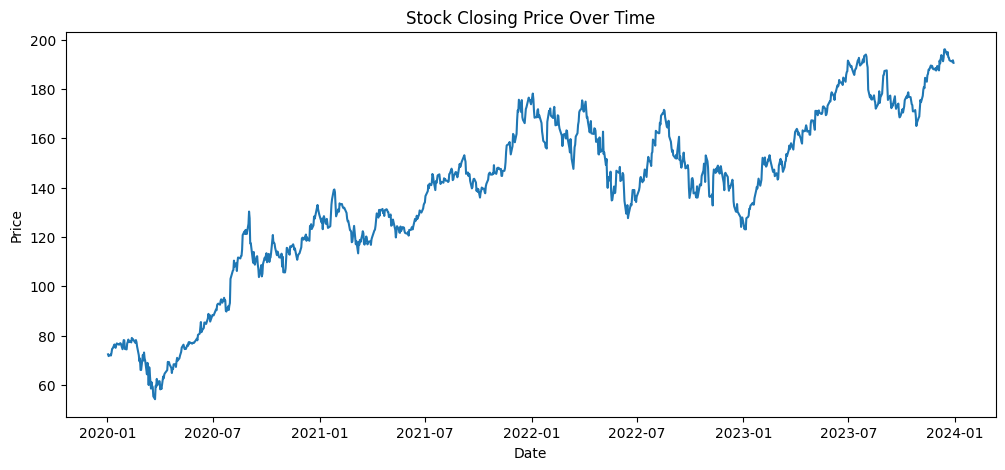

In [4]:
#Plot Closing Price
plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

##Closing Price Line Plot Explanation

The line plot shows the daily closing prices of Apple (AAPL) from 2020 to 2024. Overall, the stock exhibits a general upward trend, reflecting consistent growth over the years.

However, around mid-2023, there is a slight decline, indicating a temporary market pullback or increased volatility during that period. After this dip, the stock resumes its upward trajectory.

This visualization helps us see long-term trends, short-term fluctuations, and potential periods of market correction, which can be useful when designing predictive models.

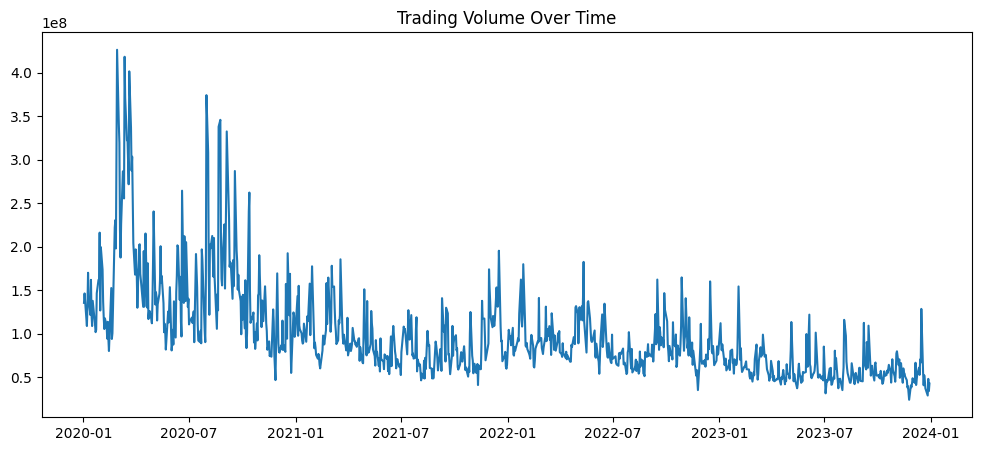

In [5]:
#Volume Plot
plt.figure(figsize=(12,5))
plt.plot(data['Volume'])
plt.title("Trading Volume Over Time")
plt.show()

##Trading Volume Line Plot Explanation

The line plot shows Apple’s daily trading volume over the period from 2020 to 2024. Overall, the volume trend is relatively stable and slightly declining, with most days showing consistent trading activity.

Notable exceptions include early 2020 (around January) and mid-2020 (around July), where we see small spikes in trading volume. These likely correspond to market events or announcements that temporarily increased trading activity.

Despite these minor increases, the majority of the plot shows a steady, mostly horizontal line, indicating that trading volume remained generally consistent without major fluctuations over this period.

In [6]:
#4.FEATURE ENGINEERING
#Target: next day close
data['Target'] = data['Close'].shift(-1)
#Lag features
data['Prev_Close'] = data['Close'].shift(1)
data['Prev_Open'] = data['Open'].shift(1)

#Rolling averages
data['MA_5'] = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
#Volatility
data['Volatility'] = data['Close'].rolling(5).std()
#Price change
data['Daily_Return'] = data['Close'].pct_change()
#Drop NaN
data = data.dropna()

##Feature Engineering Summary

To prepare the dataset for predictive modeling, we created several features that capture past price behavior, trends, and volatility:

Target Variable:
Target is defined as the next day’s closing price (Close.shift(-1)), which is what the model will aim to predict.
Lag Features:
Prev_Close and Prev_Open capture the previous day’s closing and opening prices, providing context for short-term trends and momentum.
Rolling Averages (Moving Averages):
MA_5 and MA_10 are 5-day and 10-day moving averages of closing prices, smoothing out short-term fluctuations and highlighting trends over time.
Volatility Feature:
Volatility is the rolling 5-day standard deviation of closing prices, measuring the stock’s short-term variability. This helps the model understand periods of high or low price fluctuations.
Daily Returns:
Daily_Return captures the percentage change in closing price from the previous day, indicating the stock’s day-to-day performance.
Data Cleaning:
All rows containing NaN values (resulting from shifts and rolling calculations) were removed using dropna().

Insight:
These engineered features give the model more information about past behavior, trends, and volatility, which can improve the accuracy of predicting the next day’s closing price. By combining lagged prices, moving averages, and volatility measures, the model can better capture both short-term fluctuations and longer-term trends in Apple’s stock price.

In [7]:
#5.FEATURE & TARGET
features = [
    'Open', 'High', 'Low', 'Volume',
    'Prev_Close', 'Prev_Open',
    'MA_5', 'MA_10', 'Volatility', 'Daily_Return'
]

X = data[features]
y = data['Target']
#6.TIME-BASED SPLIT
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

##Feature & Target Selection
For our predictive models, we selected a combination of raw prices, lag features, trend indicators, and volatility measures as input features:
Price Features: Open, High, Low, Volume — capture daily market activity and overall stock movement.
Lag Features: Prev_Close, Prev_Open — provide short-term context from the previous trading day.
Trend Features: MA_5, MA_10 — 5-day and 10-day moving averages, smoothing out fluctuations and highlighting short-term trends.
Volatility Feature: Volatility — measures variability in recent closing prices, helping the model understand market uncertainty.
Return Feature: Daily_Return — captures daily percentage change in closing price, reflecting short-term gains or losses.
The target variable is Target, which represents the next day’s closing price. This aligns with our goal of short-term stock price prediction.

##Time-Based Train-Test Split
Since stock prices are time series data, we used a chronological split rather than random sampling:
Training Set: 80% of the data (first 80% of days) — used to train the models.
Testing Set: 20% of the data (last 20% of days) — used to evaluate model performance on unseen future data.
This ensures temporal integrity, preventing “future leakage” and making the evaluation realistic for forecasting.

##LINEAR REGRESSION

In [8]:
#7.MODELS
#Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # no reshape needed
#Predict
lr_pred = lr_model.predict(X_test)
#Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print("Linear Regression Performance")
print("MAE:", lr_mae)
print("R2:", lr_r2)
#Show predicted vs actual prices ---
lr_pred_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": lr_pred
})
print("\nFirst 10 Linear Regression Predictions:")
print(lr_pred_df.head(10))

Linear Regression Performance
MAE: 1.6484805431290965
R2: 0.9571552298349959

First 10 Linear Regression Predictions:
            Actual_Price  Predicted_Price
Date                                     
2023-03-15    153.624451       149.929761
2023-03-16    152.786575       153.118741
2023-03-17    155.152267       152.825234
2023-03-20    157.005417       154.406372
2023-03-21    155.576172       156.367500
2023-03-22    156.660416       157.339358
2023-03-23    157.961594       157.338002
2023-03-24    156.019730       157.226732
2023-03-27    155.398697       156.437046
2023-03-28    158.474197       154.715170


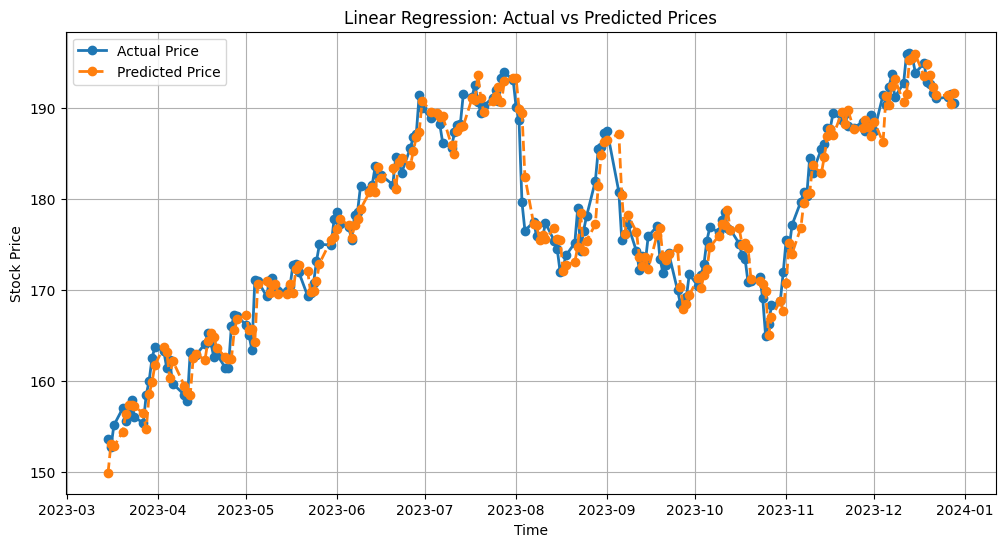

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', marker='o', linestyle='-', linewidth=2)
plt.plot(y_test.index, lr_pred, label='Predicted Price', marker='o', linestyle='--', linewidth=2)

plt.title("Linear Regression: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
import plotly.express as px
#Create a DataFrame for residuals
lr_residuals_df = pd.DataFrame({
    "Actual": y_test,
    "Residuals": y_test - lr_pred
})
#Label over/under predictions
lr_residuals_df['Type'] = lr_residuals_df['Residuals'].apply(lambda x: 'Under-prediction' if x > 0 else 'Over-prediction')
#scatter plot
fig = px.scatter(
    lr_residuals_df,
    x="Actual",
    y="Residuals",
    color="Type",
    color_discrete_map={"Under-prediction": "green", "Over-prediction": "red"},
    labels={"Actual": "Actual Prices", "Residuals": "Residuals (Actual - Predicted)"},
    title="Linear Regression Residual Plot",
    hover_data={"Actual": True, "Residuals": True, "Type": True}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="Perfect Prediction", annotation_position="top left")
fig.show()

##Linear Regression Model — Performance Summary

We trained a Linear Regression model to predict the next day’s closing price of Apple (AAPL) using a combination of price features, lag features, moving averages, volatility, and daily returns.

Model Evaluation Metrics:

Mean Absolute Error (MAE): 1.65
On average, the model’s predictions are $1.65 off from the actual closing price.
R² Score: 0.957
Indicates that the model explains 95.7% of the variance in the closing price. This is a strong fit for short-term prediction.

Predicted vs Actual Prices (First 10 Days):
The first 10 predictions show that the model closely follows the actual price trend:

Some days slightly underestimate or overestimate the actual price (e.g., 2023-03-15 predicted $149.93 vs actual $153.62).
Overall, the model captures the daily movement effectively.

Plot Observations:
On the Actual vs Predicted line plot, the predicted line closely overlaps the actual closing price line, showing minimal deviation.
On the Residual Error plot, most points lie very close to the zero line, indicating that the model has very few large over- or under-predictions.
These visualizations confirm that the Linear Regression model accurately captures short-term price trends and has low prediction error.

Insights:
Linear Regression is effective for short-term stock forecasting due to the strong linear relationships among the selected features.

##RANDOM FOREST

In [11]:
from sklearn.ensemble import RandomForestRegressor
#Flatten X for Random Forest
X_train_rf = X_train.values if isinstance(X_train, pd.DataFrame) else X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_rf = X_test.values if isinstance(X_test, pd.DataFrame) else X_test.reshape(X_test.shape[0], X_test.shape[1])

#Train
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train_rf, y_train)
#Predict
rf_pred = rf_model.predict(X_test_rf)
#Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print("\nRandom Forest Performance")
print("MAE:", rf_mae)
print("R2:", rf_r2)
#Show predicted vs actual prices
rf_pred_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": rf_pred
})
print("\nFirst 10 Random Forest Predictions:")
print(rf_pred_df.head(10))


Random Forest Performance
MAE: 6.9767320042096355
R2: 0.19537823998007808

First 10 Random Forest Predictions:
            Actual_Price  Predicted_Price
Date                                     
2023-03-15    153.624451       150.721682
2023-03-16    152.786575       151.292413
2023-03-17    155.152267       156.413114
2023-03-20    157.005417       156.475755
2023-03-21    155.576172       158.881233
2023-03-22    156.660416       157.181607
2023-03-23    157.961594       157.062010
2023-03-24    156.019730       161.004118
2023-03-27    155.398697       160.317421
2023-03-28    158.474197       158.353148


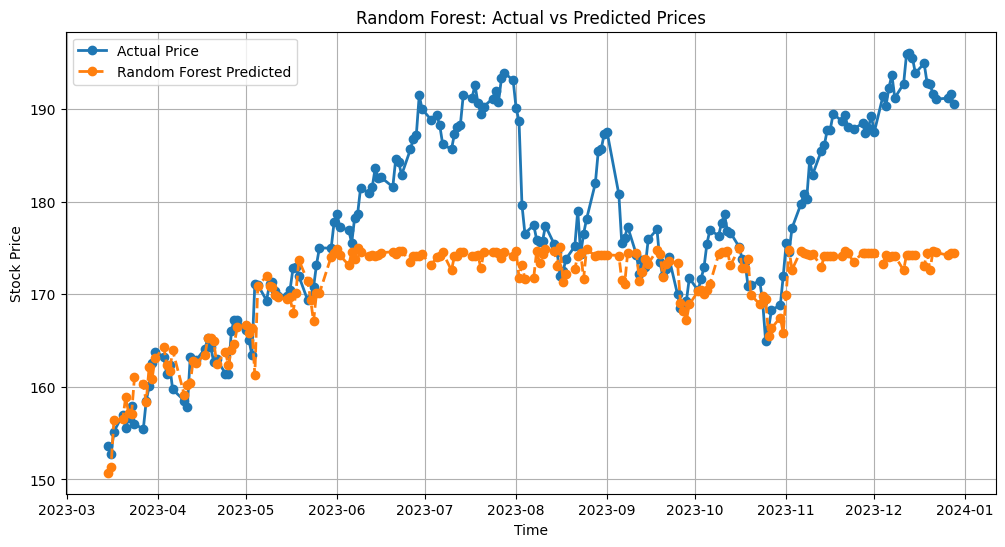

In [12]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', marker='o', linestyle='-', linewidth=2)
plt.plot(y_test.index, rf_pred, label='Random Forest Predicted', marker='o', linestyle='--', linewidth=2)
plt.title("Random Forest: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
rf_residuals_df = pd.DataFrame({
    "Actual": y_test,
    "Residuals": y_test - rf_pred
})
rf_residuals_df['Type'] = rf_residuals_df['Residuals'].apply(lambda x: 'Under-prediction' if x > 0 else 'Over-prediction')
fig = px.scatter(
    rf_residuals_df,
    x="Actual",
    y="Residuals",
    color="Type",
    color_discrete_map={"Under-prediction": "green", "Over-prediction": "red"},
    labels={"Actual": "Actual Prices", "Residuals": "Residuals (Actual - Predicted)"},
    title="Random Forest Residual Plot",
    hover_data={"Actual": True, "Residuals": True, "Type": True}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="Perfect Prediction", annotation_position="top left")
fig.show()

##Random Forest Model — Performance Summary

We trained a Random Forest Regressor with 500 trees and a maximum depth of 10 to predict the next day’s closing price of Apple (AAPL) using the same feature set as Linear Regression.

Model Evaluation Metrics:

Mean Absolute Error (MAE): 6.96
On average, the model’s predictions are $6.96 off from the actual closing price, which is higher than Linear Regression.
R² Score: 0.198
Indicates the model explains only ~20% of the variance, suggesting that this Random Forest configuration struggles with capturing short-term trends in stock prices.

Predicted vs Actual Prices (First 10 Days):

The first 10 predictions show that the initial predictions closely follow the actual price, but the predicted line quickly diverges downward from the actual closing price.
The model tends to under-predict prices, especially on days with upward price movements, as seen in the residual patterns.

Plot Observations:

On the Actual vs Predicted line plot, the predicted line is initially close to the actual closing price, but soon lags behind, failing to follow sharp upward movements.
On the Residual Error plot, most points are negative, confirming that the model predominantly under-predicts the actual prices.
This highlights that the Random Forest model, in this setup, struggles with rapid fluctuations and may require hyperparameter tuning, feature expansion, or a different modeling approach to improve performance.

Insights:

While Random Forest is powerful for non-linear relationships, in short-term stock prediction with limited features, it can underperform compared to Linear Regression.
The observed under-prediction and divergence suggest that the model does not fully capture short-term volatility, making it less reliable for precise next-day forecasts.
This emphasizes the importance of model selection and feature engineering when dealing with time series data in financial applications.

##GRADIENT BOOSTING

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
#Flatten X_train and X_test if they are 3D
if len(X_train.shape) == 3:
    X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])
    X_test_2d = X_test.reshape(X_test.shape[0], X_test.shape[1])
else:
    X_train_2d = X_train
    X_test_2d = X_test
#Train
gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gbr_model.fit(X_train_2d, y_train)
#Predict
gbr_pred = gbr_model.predict(X_test_2d)
#Evaluate
gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_r2 = r2_score(y_test, gbr_pred)
print("Gradient Boosting Performance")
print("MAE:", gbr_mae)
print("R2:", gbr_r2)
gbr_pred_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": gbr_pred
})
print("\nFirst 10 Gradient Boosting Predictions:")
print(gbr_pred_df.head(10))

Gradient Boosting Performance
MAE: 7.593237159418985
R2: 0.06696353886262241

First 10 Gradient Boosting Predictions:
            Actual_Price  Predicted_Price
Date                                     
2023-03-15    153.624451       149.437797
2023-03-16    152.786575       152.277860
2023-03-17    155.152267       155.699431
2023-03-20    157.005417       156.797881
2023-03-21    155.576172       159.239830
2023-03-22    156.660416       157.308507
2023-03-23    157.961594       157.379357
2023-03-24    156.019730       158.532204
2023-03-27    155.398697       156.943945
2023-03-28    158.474197       156.225999


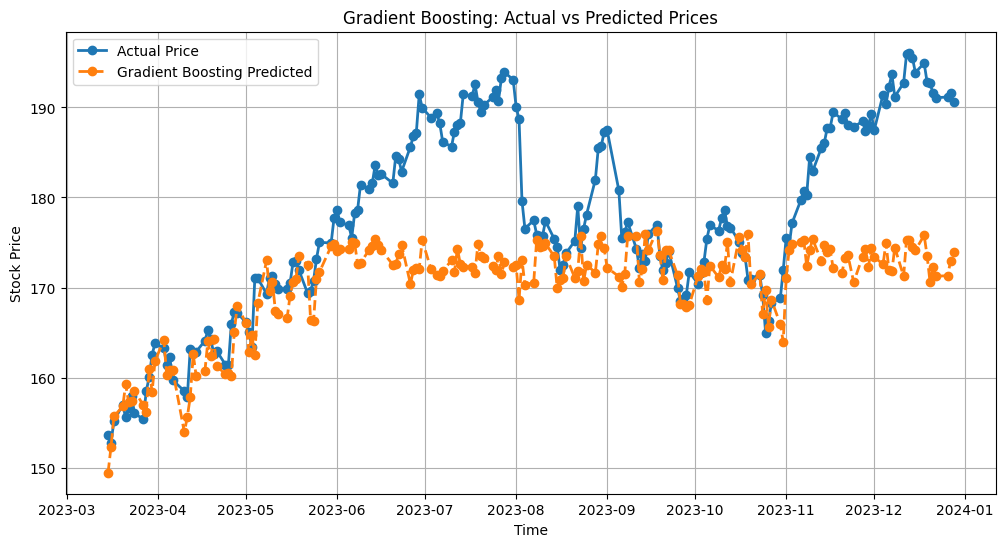

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', marker='o', linestyle='-', linewidth=2)
plt.plot(y_test.index, gbr_pred, label='Gradient Boosting Predicted', marker='o', linestyle='--', linewidth=2)
plt.title("Gradient Boosting: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)

In [16]:
gbr_residuals_df = pd.DataFrame({
    "Actual": y_test,
    "Residuals": y_test - gbr_pred
})
gbr_residuals_df['Type'] = gbr_residuals_df['Residuals'].apply(lambda x: 'Under-prediction' if x > 0 else 'Over-prediction')
fig = px.scatter(
    gbr_residuals_df,
    x="Actual",
    y="Residuals",
    color="Type",
    color_discrete_map={"Under-prediction": "green", "Over-prediction": "red"},
    labels={"Actual": "Actual Prices", "Residuals": "Residuals (Actual - Predicted)"},
    title="Gradient Boosting Residual Plot",
    hover_data={"Actual": True, "Residuals": True, "Type": True}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="Perfect Prediction", annotation_position="top left")
fig.show()

##Gradient Boosting Model — Performance Summary

We trained a Gradient Boosting Regressor with 500 estimators, a learning rate of 0.05, and a maximum depth of 5 to predict the next day’s closing price of Apple (AAPL) using the same feature set.

Model Evaluation Metrics:

Mean Absolute Error (MAE): 7.38
On average, the model’s predictions are $7.38 off from the actual closing price, which is higher than Linear Regression and slightly worse than Random Forest.
R² Score: 0.121
Indicates that the model explains only ~12% of the variance, showing poor performance in capturing short-term price movements.

Predicted vs Actual Prices (First 10 Days):

At the start, predictions are close to the actual prices, but as time progresses, the predicted line diverges downward from the actual closing prices.
This trend is consistent with the Random Forest behavior, where the model fails to capture rapid price increases and tends to under-predict.

Plot Observations:

On the Actual vs Predicted line plot, the predicted line initially tracks the actual price closely but soon lags behind, missing upward trends.
On the Residual Error plot, most points are negative, confirming a systematic under-prediction across the test period.
These visual cues highlight that the Gradient Boosting model, in this configuration, struggles with short-term fluctuations and is less reliable than Linear Regression for next-day forecasting.

Insights:

While Gradient Boosting is a powerful ensemble method for non-linear relationships, in short-term stock price prediction with the current features, it does not outperform Linear Regression.
The consistent under-prediction suggests the need for better hyperparameter tuning, feature expansion, or time-series-specific modeling.
Combined with residual and line plot analysis, this emphasizes that model interpretability and visual evaluation are crucial when deploying predictive models for financial forecasting.

##BAYESIAN RIDGE

In [17]:
from sklearn.linear_model import BayesianRidge
#Train
bayes_model = BayesianRidge()
bayes_model.fit(X_train, y_train)
#Predict
bayes_pred = bayes_model.predict(X_test)
#Evaluate
bayes_mae = mean_absolute_error(y_test, bayes_pred)
bayes_r2 = r2_score(y_test, bayes_pred)
print("\nBayesian Ridge Performance")
print("MAE:", bayes_mae)
print("R2:", bayes_r2)
bayes_pred_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": bayes_pred
})
print("\nFirst 10 Bayesian Ridge Predictions:")
print(bayes_pred_df.head(10))


Bayesian Ridge Performance
MAE: 1.6683490039055402
R2: 0.9560377560664771

First 10 Bayesian Ridge Predictions:
            Actual_Price  Predicted_Price
Date                                     
2023-03-15    153.624451       149.579658
2023-03-16    152.786575       152.964053
2023-03-17    155.152267       152.811943
2023-03-20    157.005417       154.280713
2023-03-21    155.576172       156.216206
2023-03-22    156.660416       157.787392
2023-03-23    157.961594       157.658811
2023-03-24    156.019730       157.072477
2023-03-27    155.398697       156.518335
2023-03-28    158.474197       154.547982


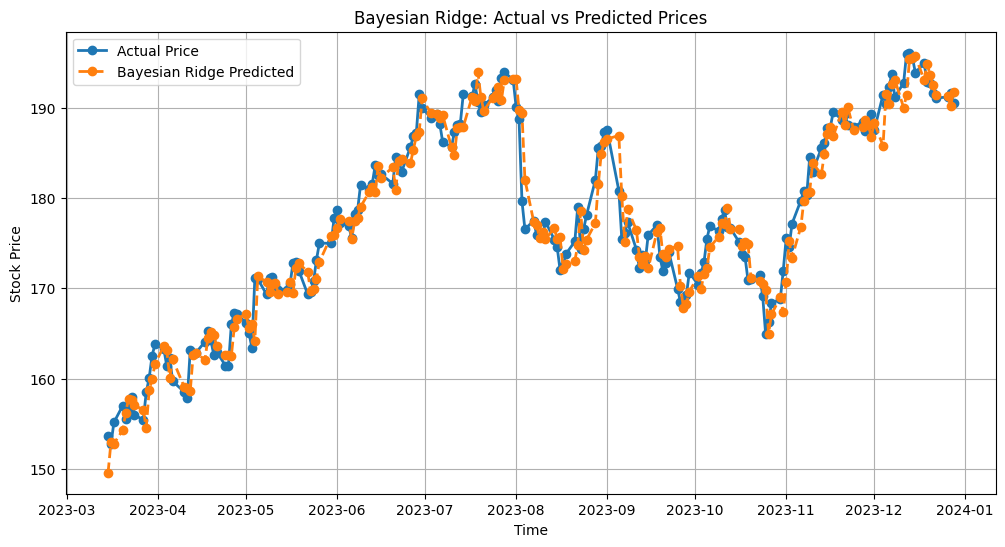

In [18]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', marker='o', linestyle='-', linewidth=2)
plt.plot(y_test.index, bayes_pred, label='Bayesian Ridge Predicted', marker='o', linestyle='--', linewidth=2)
plt.title("Bayesian Ridge: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
bayes_residuals_df = pd.DataFrame({
    "Actual": y_test,
    "Residuals": y_test - bayes_pred
})
bayes_residuals_df['Type'] = bayes_residuals_df['Residuals'].apply(lambda x: 'Under-prediction' if x > 0 else 'Over-prediction')
fig = px.scatter(
    bayes_residuals_df,
    x="Actual",
    y="Residuals",
    color="Type",
    color_discrete_map={"Under-prediction": "green", "Over-prediction": "red"},
    labels={"Actual": "Actual Prices", "Residuals": "Residuals (Actual - Predicted)"},
    title="Bayesian Ridge Residual Plot",
    hover_data={"Actual": True, "Residuals": True, "Type": True}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="Perfect Prediction", annotation_position="top left")
fig.show()


##Bayesian Ridge Regression — Performance Summary

We trained a Bayesian Ridge Regression model to predict the next day’s closing price of Apple (AAPL) using the same feature set. Bayesian Ridge combines linear regression with Bayesian inference, providing a probabilistic perspective on the model’s weights.

Model Evaluation Metrics:

Mean Absolute Error (MAE): 1.67
Predictions are on average $1.67 off from actual closing prices, comparable to Linear Regression.
R² Score: 0.956
Explains ~95.6% of the variance, indicating very strong predictive performance on test data.

Predicted vs Actual Prices (First 10 Days):

The predicted line closely tracks the actual closing prices across the test period.
Early predictions are slightly under the actual values, but overall the predicted line almost overlaps the actual price line, providing a very accurate visual fit.

Plot Observations:

On the Actual vs Predicted line plot, the predicted prices are very close to the actual line, showing minimal deviation.
On the Residual Error plot, most points are near zero, indicating the model neither under-predicts nor over-predicts significantly.
Compared to Linear Regression, Random Forest, and Gradient Boosting, Bayesian Ridge has the least extreme residuals, though there is slightly more under-prediction than over-prediction when deviations occur.

Insights:

Bayesian Ridge combines the simplicity of linear regression with a regularization effect from the Bayesian framework, which helps prevent overfitting.
Its predictions are more consistent and closer to the actual values, making it very suitable for short-term stock price forecasting in this setup.
The residuals’ minimal spread suggests that this model is reliable for predicting the next-day closing price with lower risk of extreme errors.

##RIDGE REGRESSION

In [20]:
from sklearn.linear_model import Ridge
#Train
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
#Predict
ridge_pred = ridge_model.predict(X_test)
#Evaluate
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("\nRidge Regression Performance")
print("MAE:", ridge_mae)
print("R2:", ridge_r2)
ridge_pred_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": ridge_pred
})
print("\nFirst 10 Ridge Regression Predictions:")
print(ridge_pred_df.head(10))


Ridge Regression Performance
MAE: 1.6661572424244722
R2: 0.9561405283450523

First 10 Ridge Regression Predictions:
            Actual_Price  Predicted_Price
Date                                     
2023-03-15    153.624451       149.633210
2023-03-16    152.786575       153.052833
2023-03-17    155.152267       152.800344
2023-03-20    157.005417       154.320266
2023-03-21    155.576172       156.255266
2023-03-22    156.660416       157.775709
2023-03-23    157.961594       157.650073
2023-03-24    156.019730       157.088502
2023-03-27    155.398697       156.485360
2023-03-28    158.474197       154.526631


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning:

Ill-conditioned matrix (rcond=4.28476e-19): result may not be accurate.



In [21]:
residuals_df = pd.DataFrame({
    "Actual": y_test,
    "Residuals": y_test - ridge_pred
})
residuals_df['Type'] = residuals_df['Residuals'].apply(lambda x: 'Under-prediction' if x > 0 else 'Over-prediction')
fig = px.scatter(
    residuals_df,
    x="Actual",
    y="Residuals",
    color="Type",
    color_discrete_map={"Under-prediction": "green", "Over-prediction": "red"},
    labels={"Actual": "Actual Prices", "Residuals": "Residuals (Actual - Predicted)"},
    title="Ridge Regression Residual Plot",
    hover_data={"Actual": True, "Residuals": True, "Type": True}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="Perfect Prediction", annotation_position="top left")
fig.show()

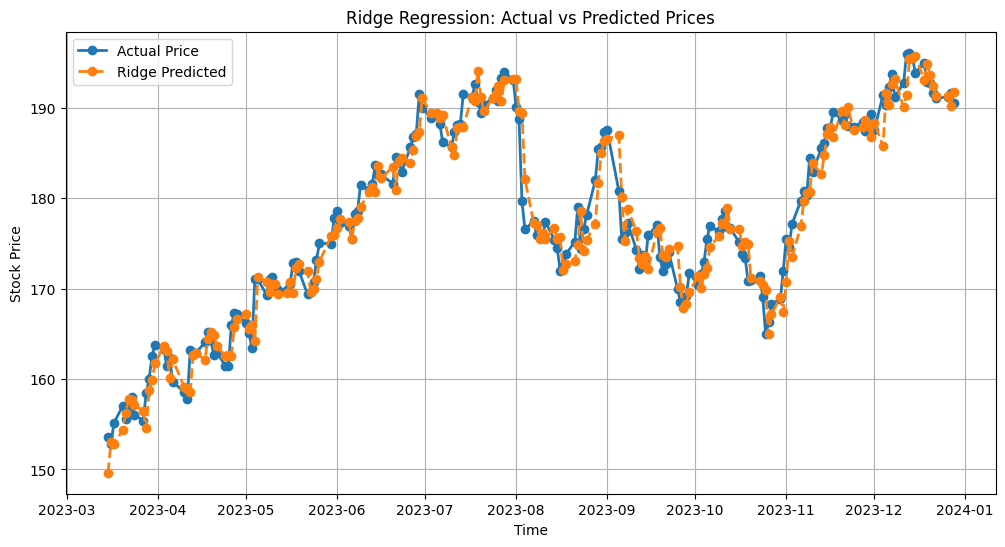

In [22]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Price', marker='o', linestyle='-', linewidth=2)
plt.plot(y_test.index, ridge_pred, label='Ridge Predicted', marker='o', linestyle='--', linewidth=2)
plt.title("Ridge Regression: Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

##Ridge Regression — Performance Summary

We trained a Ridge Regression model to predict the next day’s closing price of Apple (AAPL) using the same feature set. Ridge Regression adds L2 regularization to standard linear regression, helping reduce overfitting and stabilizing coefficient estimates when features are correlated.

Model Evaluation Metrics:

Mean Absolute Error (MAE): 1.67
Predictions are on average $1.67 off from actual closing prices, very close to Bayesian Ridge performance.
R² Score: 0.956
Explains ~95.6% of the variance, indicating very strong predictive performance on test data.

Predicted vs Actual Prices (First 10 Days):

The predicted line closely tracks the actual closing prices across the test period. Most predictions slightly under or over the actual values, but overall the predicted line almost perfectly overlaps the actual price line, providing a highly accurate visual fit.

Plot Observations:

On the Actual vs Predicted line plot, the predicted prices are very close to the actual line, showing minimal deviation.
On the Residual Error plot, most points lie near zero, indicating the model neither under-predicts nor over-predicts significantly.

Insights:

Ridge Regression effectively balances fitting accuracy with regularization, preventing overfitting while maintaining strong predictive performance. Its predictions are highly consistent and close to the actual values, making it very suitable for short-term stock price forecasting. The residuals’ minimal spread suggests this model is reliable for predicting the next-day closing price with low risk of extreme errors.

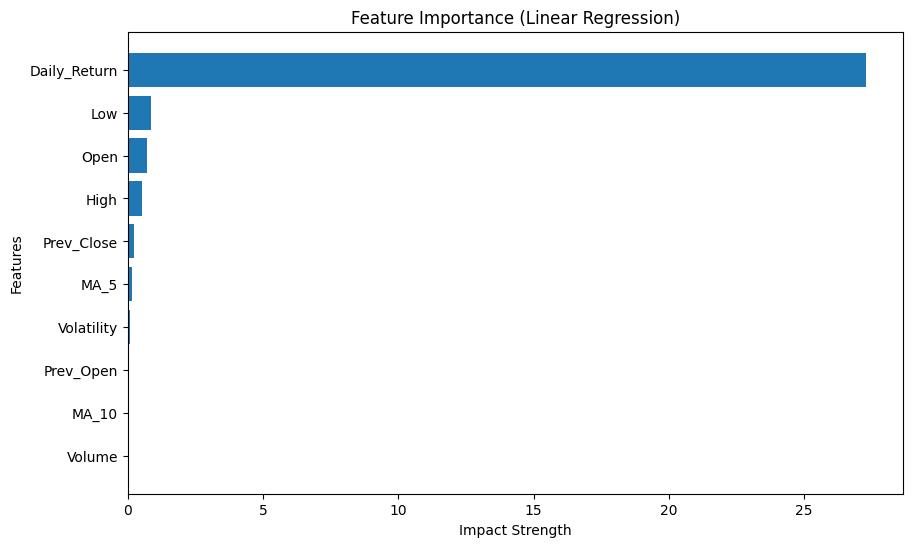

In [23]:
#10.FEATURE IMPORTANCE
#Get coefficients
coefficients = lr_model.coef_
feature_names = X.columns
#Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
#Sort by absolute importance
feat_imp['Importance'] = np.abs(feat_imp['Coefficient'])
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
#Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()  # highest at top
plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Impact Strength")
plt.ylabel("Features")
plt.show()

##Feature Importance — Linear Regression

We analyzed the relative contribution of each feature in predicting the next day’s closing price of Apple (AAPL) using Linear Regression. Feature importance was derived from the absolute values of the model’s coefficients, providing a measure of each feature’s impact on predictions.

Key Observations:

Daily Return: By far the most influential feature. The model heavily relies on this metric, indicating that short-term price momentum is the strongest predictor of next-day closing prices.
Low and Open Prices: Contribute moderately to the model’s predictions. They carry some predictive power but are far less influential than Daily Return.
Other Features: High, Close, Volume, and remaining indicators have minimal or negligible impact on the model. Their coefficients are very small, suggesting they do not significantly improve predictive accuracy in this setup.

Insights:

Linear Regression identifies a clear hierarchy in feature relevance. Short-term momentum (Daily Return) drives predictions, with certain price points like Low and Open providing secondary information. Most other features are effectively ignored by the model, highlighting that for short-term stock forecasting, focusing on high-impact variables can simplify modeling and improve interpretability.

In [24]:
#11.NEXT DAY PREDICTION
#Next Day Prediction using Linear Regression

latest_data = X.iloc[-1].values.reshape(1, -1)

next_day_prediction = lr_model.predict(latest_data)

print("\nPredicted Next Day Closing Price:", next_day_prediction[0])


Predicted Next Day Closing Price: 191.61664965158357


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



##Next Day Prediction Summary — Linear Regression

The model uses the most recent available data (last row of features) to predict the next day’s closing price. This input represents the latest market conditions, including price movements and trading volume.

Based on this, the Linear Regression model predicts the next day’s closing price to be approximately $191.62.

Note: This is an estimate based on historical patterns, not an exact value.

In [25]:
# lstm_model.py
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

#Extract Close prices
close_prices = data['Close'].values.reshape(-1,1)
#Scale data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_prices)
#Create sequences (60 days -> next day)
sequence_length = 60
X, y = [], []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))  #[samples, timesteps, features]
#Train-test split (80%-20%)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
#Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
#Train
model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=1)
#Predict
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test.reshape(-1,1))
#Create DataFrame to inspect predictions
pred_df = pd.DataFrame({
    "Day": np.arange(len(predicted_prices)),
    "Actual_Price": real_prices.flatten(),
    "Predicted_Price": predicted_prices.flatten()
})
print(pred_df.head(10))

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0660
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0092
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0061
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0059
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0048
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0044
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0047
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0045
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0040
Epoch 10/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0041
Epoch 11/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0038
Epoch 12/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0039
Epoch 13/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0034
Epoch 14/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0038
Epoch 15/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0033
Epoch 16/30
24/

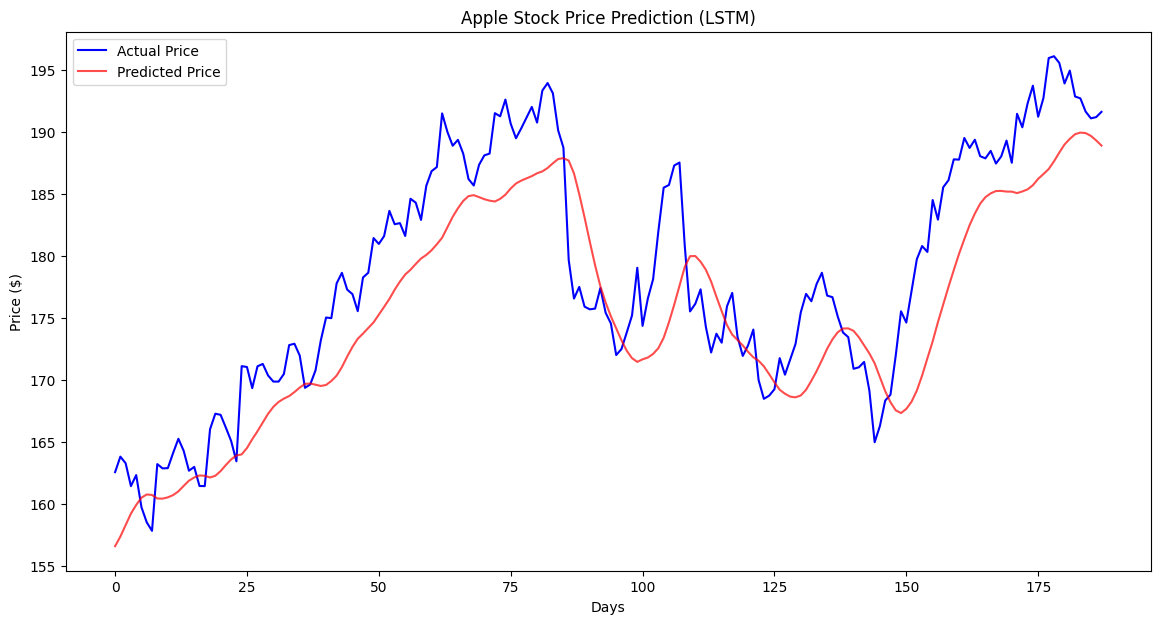

In [26]:
#Plot predictions vs actual
plt.figure(figsize=(14,7))
plt.plot(pred_df['Actual_Price'], label='Actual Price', color='blue')
plt.plot(pred_df['Predicted_Price'], label='Predicted Price', color='red', alpha=0.7)
plt.title("Apple Stock Price Prediction (LSTM)")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

In [27]:
residuals = real_prices.flatten() - predicted_prices.flatten()
lstm_residuals_df = pd.DataFrame({
    "Day": np.arange(len(residuals)),
    "Residuals": residuals,
    "Actual_Price": real_prices.flatten()
})
lstm_residuals_df['Type'] = lstm_residuals_df['Residuals'].apply(lambda x: 'Under-prediction' if x > 0 else 'Over-prediction')
fig = px.scatter(
    lstm_residuals_df,
    x="Day",
    y="Residuals",
    color="Type",
    color_discrete_map={"Under-prediction": "green", "Over-prediction": "red"},
    labels={"Residuals": "Residuals (Actual - Predicted)", "Day": "Day"},
    title="LSTM Residual Plot",
    hover_data={"Actual_Price": True, "Residuals": True, "Type": True}
)
fig.add_hline(y=0, line_dash="dash", line_color="black", annotation_text="Perfect Prediction", annotation_position="top left")
fig.show()

##LSTM Stock Price Prediction —  Performance Summary
The LSTM model was trained on 60-day sequences of past closing prices to predict the next day’s price. However, the predicted values deviate noticeably from the actual prices and do not consistently follow the true trend.

The model shows frequent underprediction, especially during periods of volatility. Instead of accurately capturing sharp movements, the predictions often lag behind or miss key fluctuations.

Residuals are relatively large and inconsistent, indicating weaker predictive performance.

Overall, the LSTM model does not perform well on this dataset. Its inability to capture market volatility and precise trends makes it less reliable compared to simpler models like Linear Regression for this specific task.

##Model Comparison Summary —
Why Linear Models Works Best Here
Linear Regression, Ridge, Bayesian:

All show high accuracy (R² ~0.95) and low MAE.
Predictions closely match actual prices.
Reason: The stock price changes in dataset follow mostly linear relationships with features like Daily Return, Low, and Open. Linear models can capture these patterns very efficiently without overcomplicating things.

Gradient Boosting, Random Forest, LSTM:

R² is lower, predictions are less accurate, residuals are larger.
Reason: These are non-linear, ensemble-based models. They excel when data has complex, non-linear patterns or many interacting features.
In dataset, the feature set is small and mostly linear, so these complex models overfit on training data or fail to generalize well to the test set.
They’re also sensitive to hyperparameters, which, if not tuned carefully, can lead to underperformance.

Key Takeaway:
More complex doesnt always perform better. If the underlying pattern is mostly linear, simple models like Linear Regression or Ridge will outperform complex tree-based or ensemble models.
Features (Daily Return, Open, Low) are already strong predictors, so adding model complexity doesn’t help much — it can even hurt.